# Stage 4 — Intrinsic Karst Vulnerability (Mole Creek prototype)

Combines Stage 2 (karst susceptibility) and Stage 3 (hydrological
connectivity) into **intrinsic karst vulnerability**. This answers: *"if something happens on the surface,
where is the underlying karst system relatively more vulnerable?"*

**Combination method:** Karst susceptibility × Hydrological connectivity
(multiplicative, not a weighted sum) — per the revised workflow plan,
matching COP's own multiplicative design (see the Framework section of
the project scope doc). Each input is normalised to 0-1 by its own
maximum before multiplying, so neither dominates just because of its
raw scale (intensity 0-4 vs. connectivity 0-3).

In [1]:
from pathlib import Path
import os
import sys
import numpy as np
import rasterio
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "src"))
from karst import classify_scores
from mapping import add_attribution, add_basemap, data_bounds, finish_map, plot_scores, scores_legend

data = Path(os.environ.get("AT3_DATA_DIR", "data"))
outpath = data / "Output_data"

with rasterio.open(outpath / "karst_intensity_mc_EPSG7855.tif") as src:
    intensity = src.read(1).astype(float)
    profile = src.profile
with rasterio.open(outpath / "connectivity_mc_EPSG7855.tif") as src:
    connectivity = src.read(1).astype(float)
with rasterio.open(outpath / "dem_mc_EPSG7855.tif") as src:
    dem = src.read(1)
    dem_nodata = src.nodata

valid = dem != dem_nodata

## 4.1 Normalise and combine

In [2]:
intensity_norm = intensity / 4.0       # max KCATEGORY score from Stage 2
connectivity_norm = connectivity / 3.0  # max connectivity score from Stage 3

intrinsic = intensity_norm * connectivity_norm
intrinsic[~valid] = np.nan

print("Distinct combined score values present:", np.unique(intrinsic[valid]))

Distinct combined score values present: [0.     0.1875 0.25   0.375  0.5    0.75   1.    ]


## 4.2 Classify

Classified directly on whatever distinct combined values occur (via `classify_scores()` in `src/karst.py`). A handful of discrete ordinal inputs produces only a few real combinations, so exact-value classes are more meaningful than quantile breaks. Labels are generated from the values present, so a change to the upstream scoring flows through without edits here.

Class distribution (valid cells):
  None (score=0.0000): 1431277 cells (77.4%)
  Very Low (score=0.1875): 49386 cells (2.7%)
  Low-Moderate (score=0.2500): 10678 cells (0.6%)
  Moderate (score=0.3750): 106024 cells (5.7%)
  High (score=0.5000): 217761 cells (11.8%)
  Very High (score=0.7500): 30119 cells (1.6%)
  Extreme (score=1.0000): 3165 cells (0.2%)


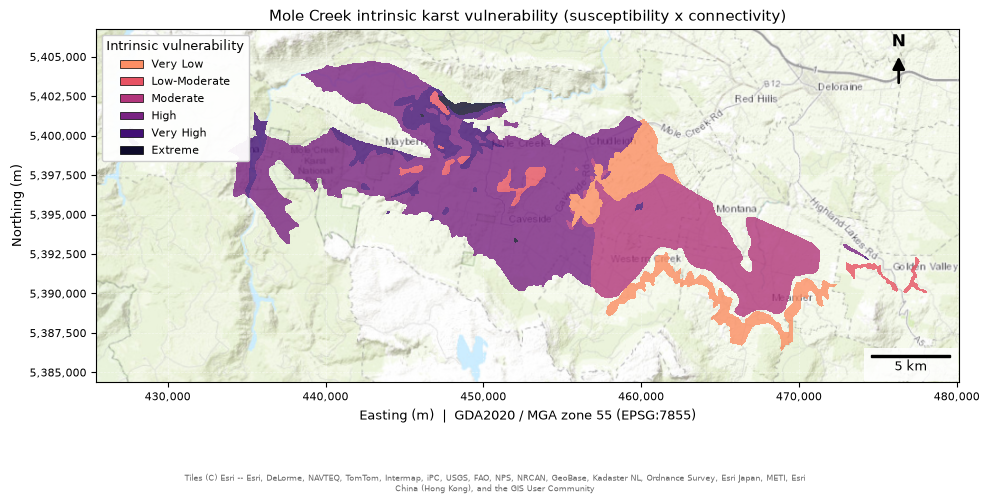

In [3]:
intrinsic_class, present, LABELS = classify_scores(intrinsic, valid)

print("Class distribution (valid cells):")
for i, (val, label) in enumerate(zip(present, LABELS)):
    n = (intrinsic_class == i).sum()
    print(f"  {label} (score={val:.4f}): {n} cells ({n/valid.sum()*100:.1f}%)")

out_profile = profile.copy()
out_profile.update(dtype="uint8", nodata=255)
with rasterio.open(outpath / "intrinsic_vulnerability_mc_EPSG7855.tif", "w", **out_profile) as dst:
    dst.write(intrinsic_class, 1)

# Also save the continuous (unclassified) score -- Stage 6 needs the real
# relative spacing, not the class index, which would distort it
intrinsic_raw = np.where(valid, intrinsic, -9999).astype("float32")
raw_profile = profile.copy()
raw_profile.update(dtype="float32", nodata=-9999)
with rasterio.open(outpath / "intrinsic_vulnerability_raw_mc_EPSG7855.tif", "w", **raw_profile) as dst:
    dst.write(intrinsic_raw, 1)

bounds = data_bounds(valid & (intrinsic > 0), profile["transform"])
fig, ax = plt.subplots(figsize=(10, 5.6))
add_basemap(ax, bounds, zoom=11)
plot_scores(ax, intrinsic_class, profile["transform"], len(present))
scores_legend(ax, LABELS, title="Intrinsic vulnerability")
ax.set_title("Mole Creek intrinsic karst vulnerability (susceptibility x connectivity)", fontsize=11)
finish_map(ax)
add_attribution(ax)
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()


## Connectivity now varies across Mole Creek

With D8 flow-routing connectivity (Stage 3) the combined score takes 7 distinct values (including zero), because connectivity runs through four classes (0.75, 1.5, 2.25 and 3 on the 0-3 scale) across the karst instead of sitting at 2 or 3. Most of the Mole Creek polygons fall in class 2 (41 of 66), and four reach the top class.

For `discussion.md`: the routed score depends on the DEM resolution and on the class edges, which are fixed powers of ten (Stage 13 compares 2 m, 25 m and 100 m). The Atlas version, version 2, is still available in `connectivity_atlas_mc_EPSG7855.tif`.

## Stage 4 outputs

- `intrinsic_vulnerability_mc_EPSG7855.tif` — classified intrinsic vulnerability (labels generated from the values present; see printed output above)
- `intrinsic_vulnerability_raw_mc_EPSG7855.tif` — continuous (unclassified) score, used by Stage 6

**Next (Stage 5):** land-use pressure from DEA Level-3 land cover, the first layer that should vary *outside* the karst polygons themselves, now that the Mole Creek boundary includes surrounding land (see the buffer in Stage 0).